In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
%matplotlib widget

import matplotlib.pyplot as plt


import moabb
import numpy as np
import seaborn as sns
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Tensorflow not install, you could not use those pipelines
To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [2]:
from moabb.paradigms import P300
from moabb.datasets import BNCI2014_008, BNCI2014_009
plt.style.use('default')

fmax=16
sfreq=32 
paradigm = P300(resample=sfreq, tmin=-0.2, tmax=1.0, fmin=0.5, fmax=fmax)
dataset = BNCI2014_009()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)

Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/paradigms/base.py:346: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
epochs


Number of events,1728
Events,NonTarget: 1440Target: 288
Time range,-0.188 – 0.969 s
Baseline,off


In [4]:
meta

,subject,session,run
0,1,session_0,run_0
1,1,session_0,run_0
2,1,session_0,run_0
3,1,session_0,run_0
4,1,session_0,run_0
...,...,...,...
1723,1,session_2,run_0
1724,1,session_2,run_0
1725,1,session_2,run_0
1726,1,session_2,run_0


In [44]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from mne.decoding import Scaler

tl.set_backend('numpy')

X = epochs.get_data().astype(np.float32)
X = Scaler(with_mean=False, scalings='mean').fit_transform(X)
y = labels

X.shape


(1728, 16, 38)

In [45]:
import cupy
from hoda.hoda import HODA, mode_scatter, center
from hoda.tenalg import trunc_eigh, lanczos, pinvh
import cupyx
import cupy.linalg


hoda = HODA(
            rank=[2,2],
            max_iter=32,
            tol=1e-8,
            init ='mlsvd',
            shrinkage=(0,0),
            toeplitz=None,
            obj='diff',
            solver='lanczos',
            taper=False,
            keep_train_info=False,
            verbose=True,
        )
%lprun -f hoda.fit hoda.fit(X,y)

Initializing factors...
Fitting discriminative tucker model...


  0%|          | 0/32 [00:00<?, ?it/s]

Fitted tucker model of rank [2, 2] ...


Timer unit: 1e-09 s

Total time: 10.6093 s
File: /data/Workspace/PhD/hoda-bci/hoda/hoda.py
Function: fit at line 230

Line #      Hits         Time  Per Hit   % Time  Line Contents
   230                                               def fit(self, X, y):
   231                                                   # Setup
   232         1    1251731.0    1e+06      0.0          X = tl.tensor(X.copy(), dtype=X.dtype)
   233         1     230646.0 230646.0      0.0          self.classes_, class_counts = np.unique(y, return_counts=True)
   234         1       6991.0   6991.0      0.0          class_counts = tl.tensor(class_counts)
   235         1       1944.0   1944.0      0.0          n_samples, *shape = X.shape
   236         1        461.0    461.0      0.0          order = len(shape)
   237         1        439.0    439.0      0.0          if self.rank is None:
   238                                                       self.rank_ = shape.copy()
   239                                   

In [23]:
if hoda.keep_train_info:
    fig, axs = plt.subplots(6,1, sharex=True, figsize=(6,10))

    axs[0].set_title('F-statistic')
    axs[0].plot(hoda.train_info_["f_stat"])

    axs[1].set_title('Objective')
    axs[1].semilogy(np.asarray(hoda.train_info_["mode_objective"]).T, label=['Mode 0', 'Mode 1'])
    axs[1].legend()

    axs[2].set_title('MSE')
    axs[2].semilogy(hoda.train_info_["mse"])

    axs[3].set_title('Update')
    axs[3].semilogy(cupy.asnumpy(cupy.asarray(hoda.train_info_["mode_update"])).T, label=['Mode 0', 'Mode 1'])
    axs[3].legend()

    axs[4].set_title('Shrinkage')
    axs[4].plot(np.asarray(hoda.train_info_["mode_shrinkage"]).T, label=['Mode 0', 'Mode 1'])
    axs[4].legend()
    
    axs[5].set_title('Sparsity coefficient')
    axs[5].plot([l.get() for l in hoda.train_info_['lambd']])
    axs[5].legend()

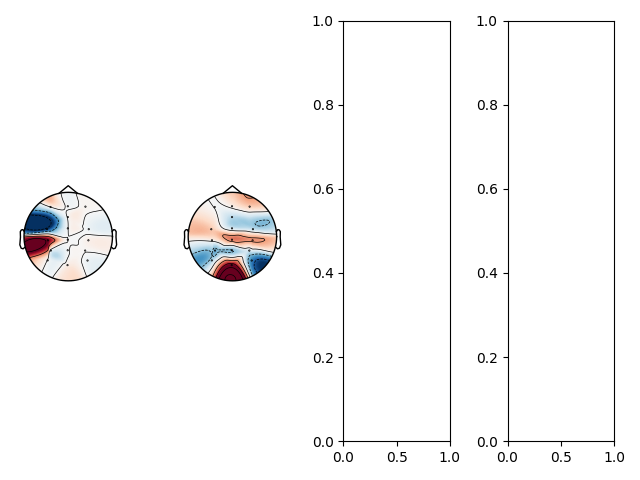

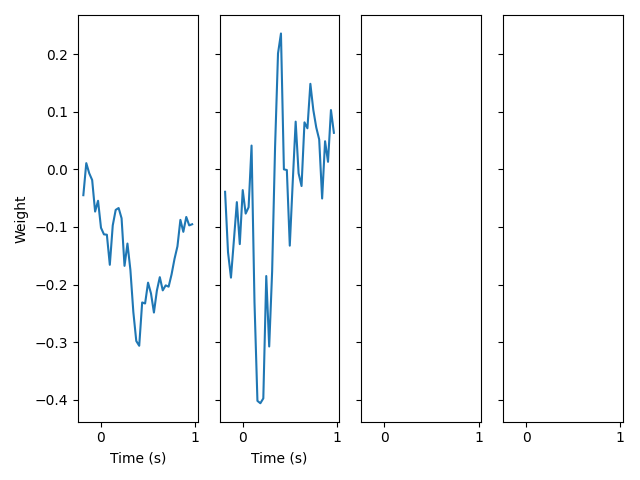

In [24]:
col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
for i in range(hoda.rank_[0]):
    w = cupy.asnumpy(hoda.scalings_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)

n_row = int( np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_[1]):
    w = cupy.asnumpy(hoda.scalings_[1][:,i])
    axs.flatten()[i].plot(epochs.times, w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


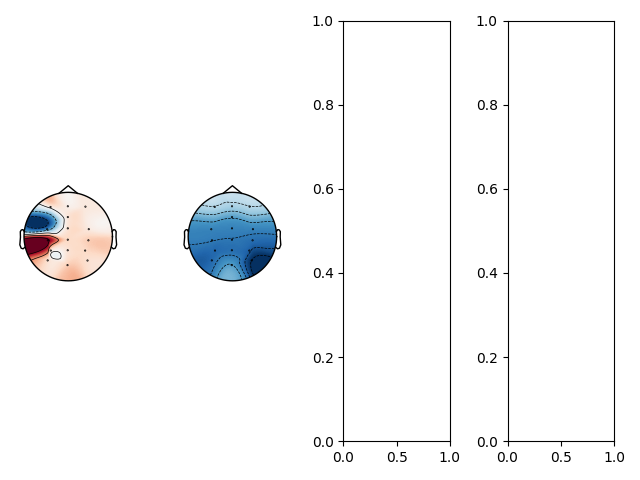

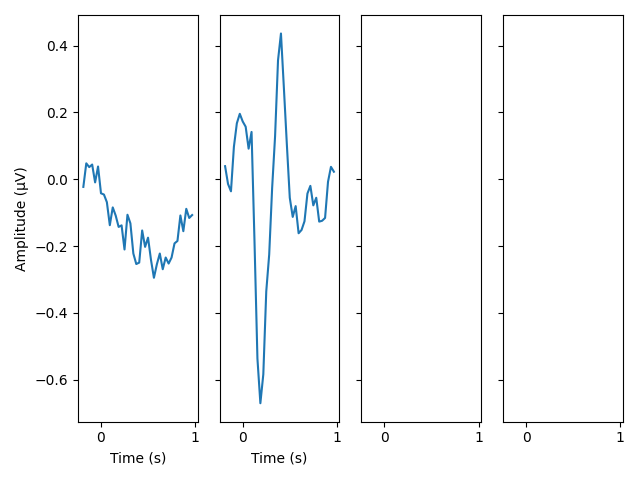

In [25]:
n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
for i in range(hoda.rank_[0]):
    a = cupy.asnumpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_[1]):
    a = cupy.asnumpy(A[:,i])
    axs.flatten()[i].plot(epochs.times, a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude (µV)');

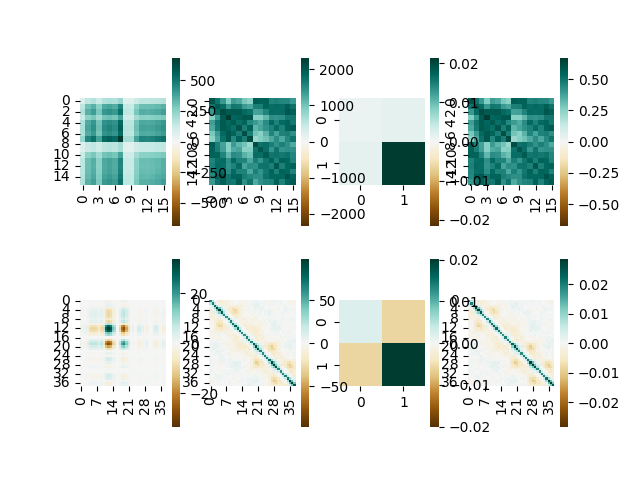

In [26]:
_, axs = plt.subplots(2,4,)
for k in range(2):
    
    scatter_b = cupy.asnumpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    axs[k,0].set_aspect('equal')
    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,0])    
    
    scatter_w = cupy.asnumpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(scatter_w))
    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,1])    
    axs[k,1].set_aspect('equal')


    cov_l= cupy.asnumpy(hoda.cov_l_[k])
    vmax = np.max(np.abs(cov_l))
    sns.heatmap(cov_l, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,2])    
    axs[k,2].set_aspect('equal')


    cov_w=  cupy.asnumpy(hoda.cov_w_[k])
    vmax = np.max(np.abs(cov_w))
    sns.heatmap(cov_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,3])    
    axs[k,3].set_aspect('equal')

In [27]:
Xt = hoda.transform(X)

In [28]:
"""
from sklearn.manifold import TSNE
import math

Xt_viz = cupy.asnumpy(Xt.reshape((Xt.shape[0],-1)))
if Xt_viz.shape[-1] > 3:
    tsne  = TSNE(n_components=min(3, math.prod(Xt.shape[1:])), n_jobs=-1)
    Xt_viz = tsne.fit_transform(Xt_viz)
fig = plt.figure()
if Xt_viz.shape[-1] == 2:
    ax = fig.add_subplot()
    ax.scatter(Xt_viz[y=='Target'][:,0], Xt_viz[y=='Target'][:,1])
    ax.scatter(Xt_viz[y=='NonTarget'][:,0], Xt_viz[y=='NonTarget'][:,1])
else:
    ax = fig.add_subplot(projection='3d')
    ax.scatter(Xt_viz[y=='Target'][:,0], Xt_viz[y=='Target'][:,1], Xt_viz[y=='Target'][:,2])
    ax.scatter(Xt_viz[y=='NonTarget'][:,0], Xt_viz[y=='NonTarget'][:,1], Xt_viz[y=='NonTarget'][:,2])
fig.show()
"""

"\nfrom sklearn.manifold import TSNE\nimport math\n\nXt_viz = cupy.asnumpy(Xt.reshape((Xt.shape[0],-1)))\nif Xt_viz.shape[-1] > 3:\n    tsne  = TSNE(n_components=min(3, math.prod(Xt.shape[1:])), n_jobs=-1)\n    Xt_viz = tsne.fit_transform(Xt_viz)\nfig = plt.figure()\nif Xt_viz.shape[-1] == 2:\n    ax = fig.add_subplot()\n    ax.scatter(Xt_viz[y=='Target'][:,0], Xt_viz[y=='Target'][:,1])\n    ax.scatter(Xt_viz[y=='NonTarget'][:,0], Xt_viz[y=='NonTarget'][:,1])\nelse:\n    ax = fig.add_subplot(projection='3d')\n    ax.scatter(Xt_viz[y=='Target'][:,0], Xt_viz[y=='Target'][:,1], Xt_viz[y=='Target'][:,2])\n    ax.scatter(Xt_viz[y=='NonTarget'][:,0], Xt_viz[y=='NonTarget'][:,1], Xt_viz[y=='NonTarget'][:,2])\nfig.show()\n"

/tmp/ipykernel_34746/2128715286.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs= plt.subplots(1,2)


<Axes: >

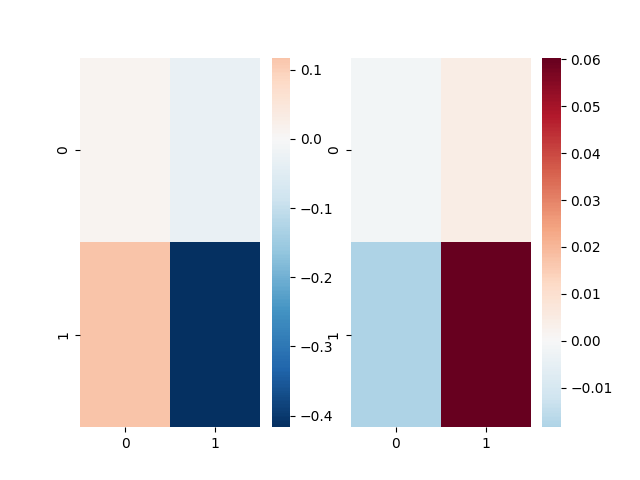

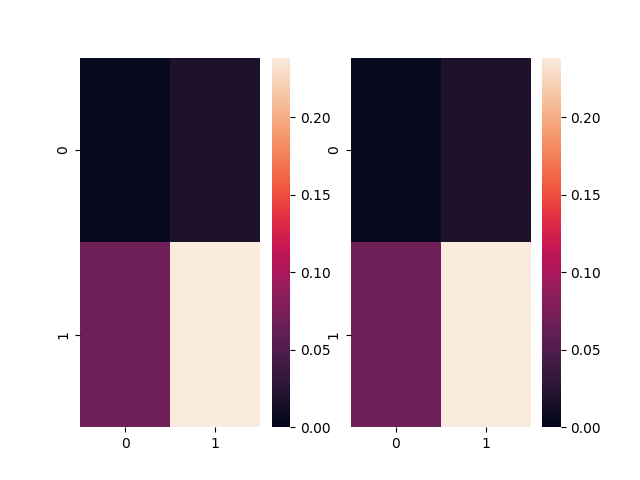

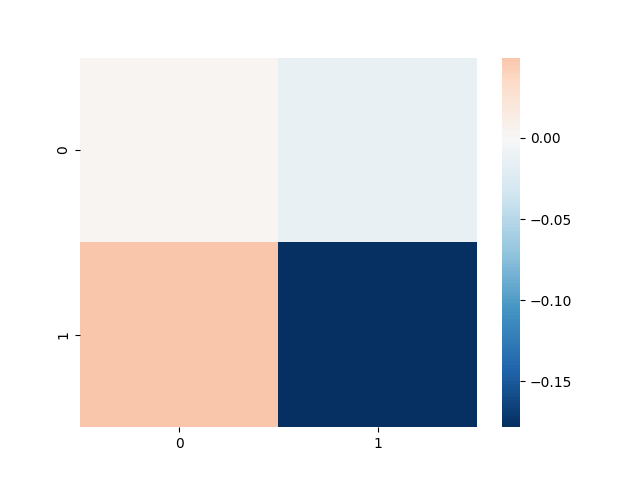

In [29]:
target_avg = cupy.asnumpy(Xt[y=='Target'].mean(axis=0))
nontarget_avg = cupy.asnumpy(Xt[y=='NonTarget'].mean(axis=0))
fig, axs= plt.subplots(1,2)
sns.heatmap(target_avg, ax=axs[0], center=0, cmap='RdBu_r')
sns.heatmap(nontarget_avg, ax=axs[1], center=0, cmap='RdBu_r')

mean_avg = (target_avg+nontarget_avg)/2
target_avg -= mean_avg
nontarget_avg -= mean_avg
fig, axs= plt.subplots(1,2)
sns.heatmap(np.abs(target_avg), ax=axs[0], vmin=0)
sns.heatmap(np.abs(nontarget_avg), ax=axs[1],vmin=0)

fig, ax= plt.subplots(1,1)

sns.heatmap(mean_avg, ax=ax, center=0, cmap='RdBu_r')


<Axes: >

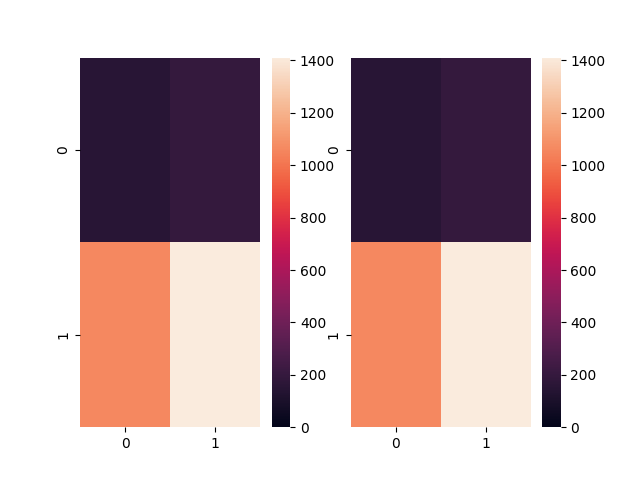

In [30]:
import scipy.stats
import seaborn as sns

samples = []
for c in hoda.classes_:
    samples.append(cupy.asnumpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
p = np.nan_to_num(p, nan=1)
fig, axs = plt.subplots(1,2)
sns.heatmap(F, vmin=0, ax=axs[0])
sns.heatmap(F, mask=p>0.05,vmin=0, ax=axs[1])


In [31]:

p_sp = np.zeros(hoda.rank_[0])
p_tmp = np.zeros(hoda.rank_[1])

for r in range(hoda.rank_[0]):
    _,p_sp[r] = scipy.stats.combine_pvalues(p[r,:])
for r in range(hoda.rank_[1]):

    _,p_tmp[r] = scipy.stats.combine_pvalues(p[:,r])

print(p_sp)
print(p_tmp)

[2.07098712e-72 0.00000000e+00]
[2.91644900e-211 5.21370951e-265]


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


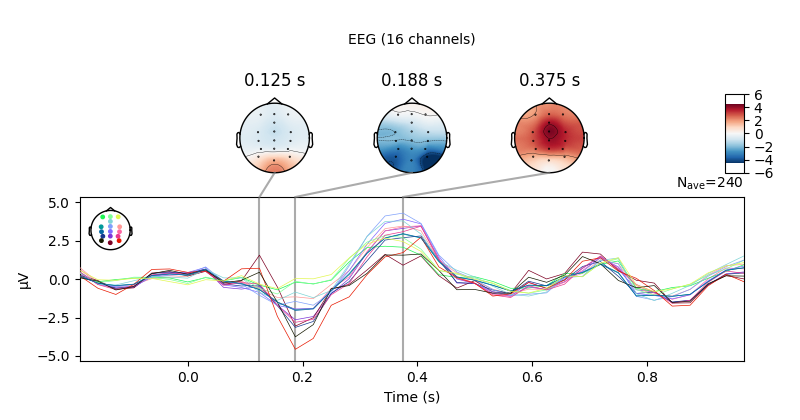

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


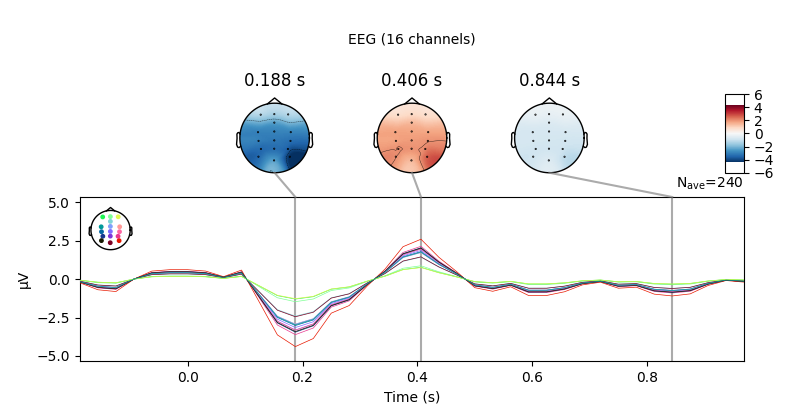

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


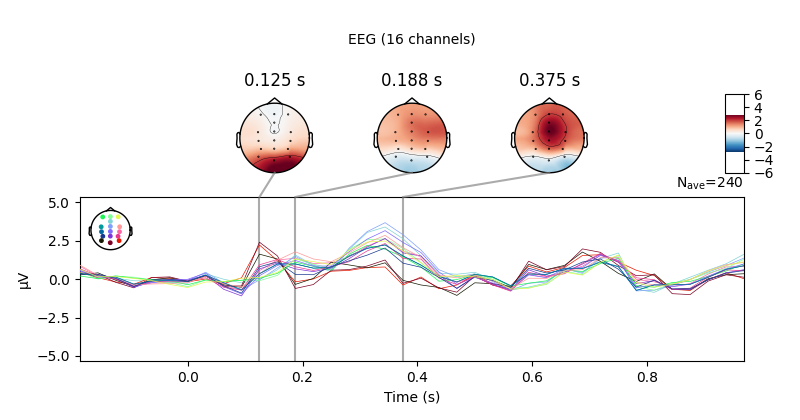

In [32]:
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
vmax = np.max(np.abs(target.data))
vmax = max(vmax, np.max(np.abs(non_target.data)))
vmax *=1.1e6

joint_args=dict(
    ts_args=dict(
        ylim=dict(eeg=[-vmax,vmax]),
        unit=True,
    )
)


contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.apply_baseline((-0.2,0)).plot_joint(**joint_args)

epochs_rec = epochs.copy()
epochs_rec._data = cupy.asnumpy(hoda.inv_transform(hoda.transform(epochs.get_data())))

target = epochs_rec['Target'].average()
non_target = epochs_rec['NonTarget'].average()
contrast_rec = combine_evoked([target, non_target], weights=[1,-1])
_= contrast_rec.apply_baseline((-0.2,0)).plot_joint(**joint_args)

epochs_defl = epochs.copy()
epochs_defl._data -= epochs_rec.get_data()

target = epochs_defl['Target'].average()
non_target = epochs_defl['NonTarget'].average()
contrast_defl = combine_evoked([target, non_target], weights=[1,-1])
_= contrast_defl.apply_baseline((-0.2,0)).plot_joint(**joint_args)

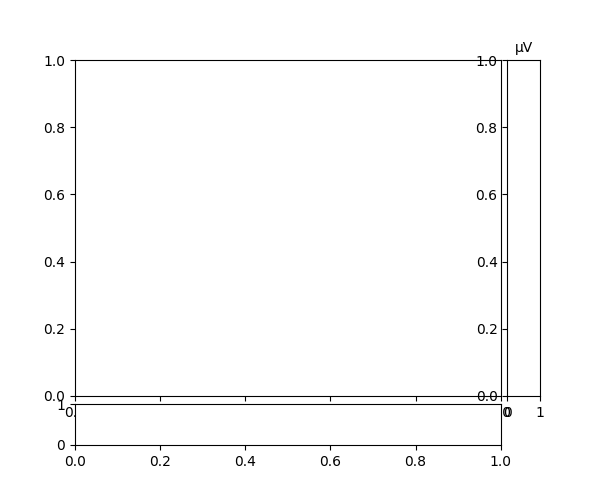

(<Figure size 600x500 with 3 Axes>,
 <matplotlib.animation.FuncAnimation at 0x7f63b6eee910>)

In [33]:
contrast_rec.animate_topomap(times = contrast_defl.times, frame_rate=contrast.info['sfreq'], blit=False, butterfly=True)

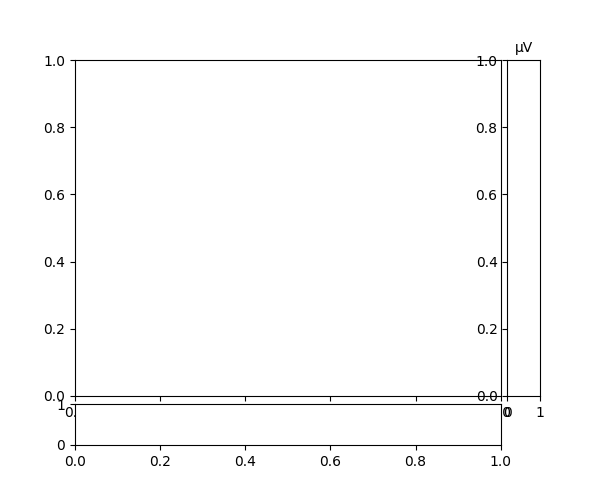

(<Figure size 600x500 with 3 Axes>,
 <matplotlib.animation.FuncAnimation at 0x7f63b6de1e90>)

In [34]:
contrast_defl.animate_topomap(times = contrast_defl.times, frame_rate=contrast.info['sfreq'], blit=False, butterfly=True)

In [35]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score

Xt = hoda.transform(X)
Xt_flat = cupy.asnumpy(Xt.reshape((Xt.shape[0],-1)))
lda = LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr') 
lda.fit(Xt_flat, y)
score_pred = lda.decision_function(Xt_flat)
print(roc_auc_score(y,score_pred))

0.959280960648148
